<h1>Predicción de tráfico</h1>

<h2>Carga de datos</h2> 

In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np

traffic = pd.read_csv('traffic.csv')
traffic

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


In [2]:
traffic.isna().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

<h2>Codificación</h2>

In [3]:
from sklearn.preprocessing import OneHotEncoder

cruces = pd.DataFrame(traffic.get('Junction'))

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(cruces)

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out())

df_encoded = pd.concat([traffic, one_hot_df], axis=1)

traffic_encoded = df_encoded.drop(cruces, axis=1)

traffic_encoded

,DateTime,Vehicles,ID,Junction_1,Junction_2,Junction_3,Junction_4
0,2015-11-01 00:00:00,15,20151101001,1.0,0.0,0.0,0.0
1,2015-11-01 01:00:00,13,20151101011,1.0,0.0,0.0,0.0
2,2015-11-01 02:00:00,10,20151101021,1.0,0.0,0.0,0.0
3,2015-11-01 03:00:00,7,20151101031,1.0,0.0,0.0,0.0
4,2015-11-01 04:00:00,9,20151101041,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,11,20170630194,0.0,0.0,0.0,1.0
48116,2017-06-30 20:00:00,30,20170630204,0.0,0.0,0.0,1.0
48117,2017-06-30 21:00:00,16,20170630214,0.0,0.0,0.0,1.0
48118,2017-06-30 22:00:00,22,20170630224,0.0,0.0,0.0,1.0


<h2>Limpieza</h2>

In [4]:
import datetime as dt
traffic_encoded['DateTime'] = pd.to_datetime(traffic_encoded['DateTime'])

traffic_encoded['Hour'] = traffic_encoded['DateTime'].dt.hour
traffic_encoded['DayOfWeek'] = traffic_encoded['DateTime'].dt.dayofweek
traffic_encoded['Month'] = traffic_encoded['DateTime'].dt.month

traffic_encoded['IsWeekend'] = (traffic_encoded['DayOfWeek'] >= 5).astype(int)

traffic_encoded

,DateTime,Vehicles,ID,Junction_1,Junction_2,Junction_3,Junction_4,Hour,DayOfWeek,Month,IsWeekend
0,2015-11-01 00:00:00,15,20151101001,1.0,0.0,0.0,0.0,0,6,11,1
1,2015-11-01 01:00:00,13,20151101011,1.0,0.0,0.0,0.0,1,6,11,1
2,2015-11-01 02:00:00,10,20151101021,1.0,0.0,0.0,0.0,2,6,11,1
3,2015-11-01 03:00:00,7,20151101031,1.0,0.0,0.0,0.0,3,6,11,1
4,2015-11-01 04:00:00,9,20151101041,1.0,0.0,0.0,0.0,4,6,11,1
...,...,...,...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,11,20170630194,0.0,0.0,0.0,1.0,19,4,6,0
48116,2017-06-30 20:00:00,30,20170630204,0.0,0.0,0.0,1.0,20,4,6,0
48117,2017-06-30 21:00:00,16,20170630214,0.0,0.0,0.0,1.0,21,4,6,0
48118,2017-06-30 22:00:00,22,20170630224,0.0,0.0,0.0,1.0,22,4,6,0


In [5]:
traffic_encoded.drop(columns=['ID', "DateTime"], inplace=True)

<h2>Dividimos los datos</h2>

In [6]:
from sklearn.model_selection import train_test_split
target_values = traffic_encoded.get('Vehicles')
traffic_encoded.drop(columns=['Vehicles'], inplace=True)

x_train, x_test, y_train, y_test = train_test_split(traffic_encoded, target_values, train_size = 0.8, random_state = 1234)

<h2>Predicción de tráfico con KNN</h2>

In [7]:
from sklearn.neighbors import KNeighborsRegressor as KNN

k = int(np.round(np.sqrt(traffic.shape[0])))
knn = KNN(n_neighbors=k)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
y_pred_knn

array([24.76712329, 39.33333333, 28.98173516, ..., 20.43378995,
       18.91780822,  9.62100457], shape=(9624,))

In [8]:
pd.DataFrame({"Predicciones" :y_pred_knn,"Valores reales": y_test})

,Predicciones,Valores reales
13618,24.767123,49
6996,39.333333,55
43578,28.981735,44
11832,35.374429,68
48068,31.319635,23
...,...,...
11501,20.958904,38
18626,14.648402,6
6175,20.433790,25
30720,18.917808,3


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

print(f'MAE: {mean_absolute_error(y_test, y_pred_knn)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_knn)}')
print(f'R²: {r2_score(y_test, y_pred_knn)}')


MAE: 10.849602117233553
MSE: 226.2071916681646
R²: 0.4646624495372621


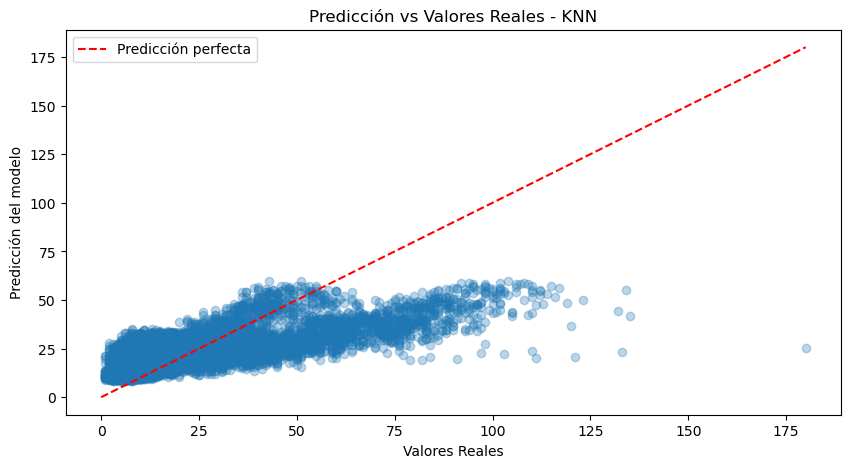

In [10]:
import matplotlib.pyplot as plt
max_val = max(y_test.max(), y_pred_knn.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - KNN')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()

<h2>Predicción de tráfico con una Red Neuronal</h2>

In [11]:
from sklearn.neural_network import MLPRegressor

# Usaremos un perceptrón multicapa
clf = MLPRegressor(random_state=1, max_iter=500)

clf.fit(x_train, y_train)

y_pred_nn = clf.predict(x_test)
y_pred_nn

array([38.17156686, 60.26404729, 18.41523821, ..., 35.46457402,
       14.42427961,  7.01666702], shape=(9624,))

In [12]:
pd.DataFrame({"Predicciones" :y_pred_nn,"Valores reales": y_test})

,Predicciones,Valores reales
13618,38.171567,49
6996,60.264047,55
43578,18.415238,44
11832,51.888752,68
48068,8.067590,23
...,...,...
11501,27.219777,38
18626,13.209618,6
6175,35.464574,25
30720,14.424280,3


In [13]:
clf.score(x_test, y_test)

0.6938143350949479

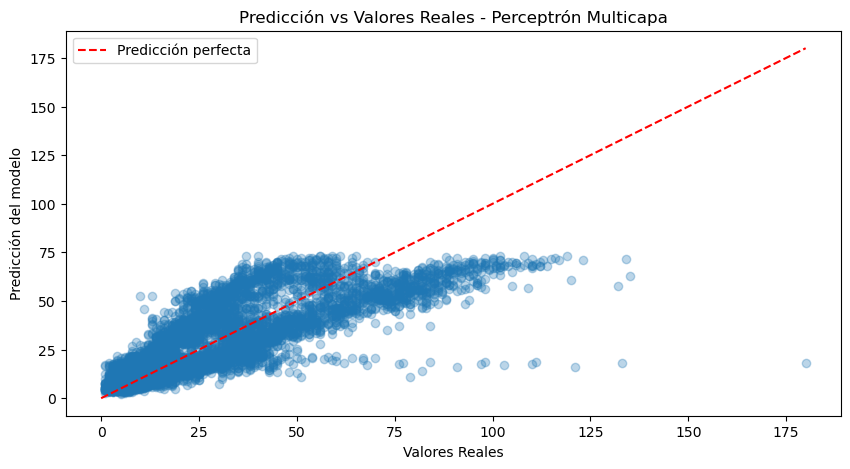

In [14]:
max_val = max(y_test.max(), y_pred_nn.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_nn, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - Perceptrón Multicapa')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()

<h2>Predicción de tráfico con Support Vector Machine</h2>

In [15]:
from sklearn.svm import SVR

svm = SVR(kernel='linear')

svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
y_pred_svm

array([37.55317061, 41.76023636, 15.81719112, ..., 39.78837002,
        9.42801239, 11.16958621], shape=(9624,))

In [16]:
pd.DataFrame({"Predicciones" :y_pred_svm,"Valores reales": y_test})

,Predicciones,Valores reales
13618,37.553171,49
6996,41.760236,55
43578,15.817191,44
11832,37.835541,68
48068,11.348166,23
...,...,...
11501,40.220631,38
18626,6.474078,6
6175,39.788370,25
30720,9.428012,3


In [17]:
svm.score(x_test, y_test)

0.5556271257665508

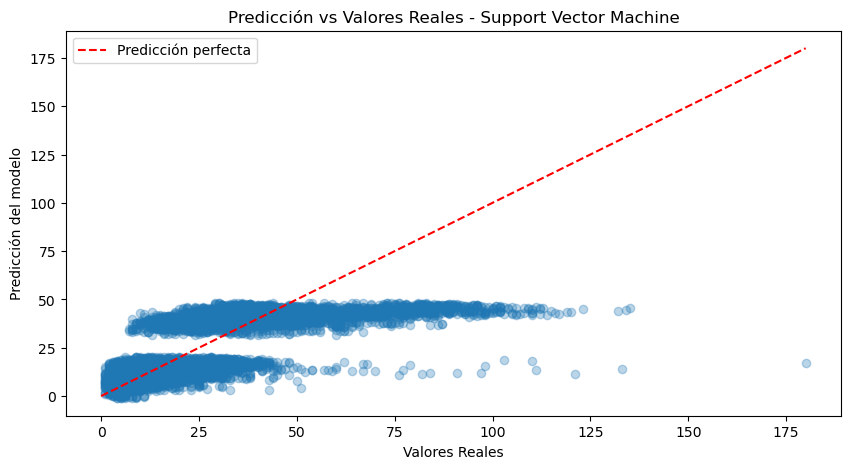

In [18]:
max_val = max(y_test.max(), y_pred_svm.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_svm, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - Support Vector Machine')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()